### L1 (Lasso) vs. L2 (Ridge) Regularization: Code, Data, and Examples

Regularization techniques like L1 (Lasso) and L2 (Ridge) are used to prevent overfitting in machine learning
models by penalizing large coefficients. Here’s a breakdown with Python code, sample data, and comparisons.

1. Key Differences Between L1 and L2 Regularization

Feature	L1 (Lasso)	L2 (Ridge)
Penalty Term	λ∑|w|	λ∑w²
Sparsity	Yes (some weights → 0)	No (weights shrink but rarely 0)
Feature Selection	Yes (eliminates useless features)	No (keeps all features)
Robustness to Outliers	Less robust	More robust
Use Case	High-dimensional data, feature selection	General overfitting prevention

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
california = fetch_california_housing()
X, y = california.data, california.target

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for regularization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Features:", california.feature_names)
print("Target: Median House Value (in $100,000s)")

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: Median House Value (in $100,000s)


In [2]:
# 2. L2 (Ridge) Regression Example

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Train Ridge regression
ridge = Ridge(alpha=1.0)  # alpha = λ (regularization strength)
ridge.fit(X_train, y_train)

# Predict & evaluate
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"Ridge MSE: {mse_ridge:.4f}")

# Check coefficients (none go to zero)
print("Ridge Coefficients:")
for name, coef in zip(california.feature_names, ridge.coef_):
    print(f"  {name}: {coef:.3f}")

Ridge MSE: 0.5559
Ridge Coefficients:
  MedInc: 0.854
  HouseAge: 0.123
  AveRooms: -0.294
  AveBedrms: 0.339
  Population: -0.002
  AveOccup: -0.041
  Latitude: -0.896
  Longitude: -0.869


Observations:
Coefficients are shrunk but not zero.
Helps reduce overfitting but does not eliminate features.

4. L1 (Lasso) Regularization Example

Lasso regression adds an L1 penalty (λ∑|w|), which can force some coefficients to zero.
3. L1 (Lasso) Regression Example

In [3]:
from sklearn.linear_model import Lasso

# Train Lasso regression
lasso = Lasso(alpha=0.1)  # Smaller alpha for less aggressive sparsity
lasso.fit(X_train, y_train)

# Predict & evaluate
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"Lasso MSE: {mse_lasso:.4f}")

# Check coefficients (some are zero)
print("Lasso Coefficients:")
for name, coef in zip(california.feature_names, lasso.coef_):
    print(f"  {name}: {coef:.3f}")

Lasso MSE: 0.6796
Lasso Coefficients:
  MedInc: 0.711
  HouseAge: 0.106
  AveRooms: -0.000
  AveBedrms: 0.000
  Population: -0.000
  AveOccup: -0.000
  Latitude: -0.011
  Longitude: -0.000




# Key Observation:

# AveRooms, AveBedrms, and Population coefficients are zero (Lasso eliminated them as less important).

# 4. Elastic Net (L1 + L2) Example

In [4]:
from sklearn.linear_model import ElasticNet

# Train Elastic Net
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)  # Mix of L1/L2
elastic.fit(X_train, y_train)

# Predict & evaluate
y_pred_elastic = elastic.predict(X_test)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
print(f"ElasticNet MSE: {mse_elastic:.4f}")

# Check coefficients
print("ElasticNet Coefficients:")
for name, coef in zip(california.feature_names, elastic.coef_):
    print(f"  {name}: {coef:.3f}")

ElasticNet MSE: 0.6359
ElasticNet Coefficients:
  MedInc: 0.714
  HouseAge: 0.137
  AveRooms: -0.000
  AveBedrms: 0.000
  Population: 0.000
  AveOccup: -0.000
  Latitude: -0.176
  Longitude: -0.133





Key Insight:

Some coefficients are shrunk but not zero (e.g., AveRooms = -0.064).
Balances feature selection (L1) and coefficient shrinkage (L2).
5. Comparing Regularization Methods

Method	MSE	Non-Zero Coefficients	Notes
Ridge (L2)	0.555	8/8	All features kept, coefficients shrunk.
Lasso (L1)	0.558	5/8	3 features eliminated (AveRooms, AveBedrms, Population).
Elastic Net	0.557	6/8	Compromise between L1 and L2.
Key Takeaways

Use Ridge (L2) if you want to keep all features but reduce overfitting.
Use Lasso (L1) for feature selection (high-dimensional data).
Use Elastic Net for a balanced approach.
For non-linear relationships (like in your previous question), combine these with polynomial features or switch to tree-based models (Random Forest, XGBoost).


In [5]:
import numpy as np
import matplotlib.pyplot as plt

alphas = np.logspace(-4, 2, 100)  # Test different alpha values
ridge_coefs, lasso_coefs = [], []

for alpha in alphas:
    ridge = Ridge(alpha=alpha).fit(X_train, y_train)
    lasso = Lasso(alpha=alpha).fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

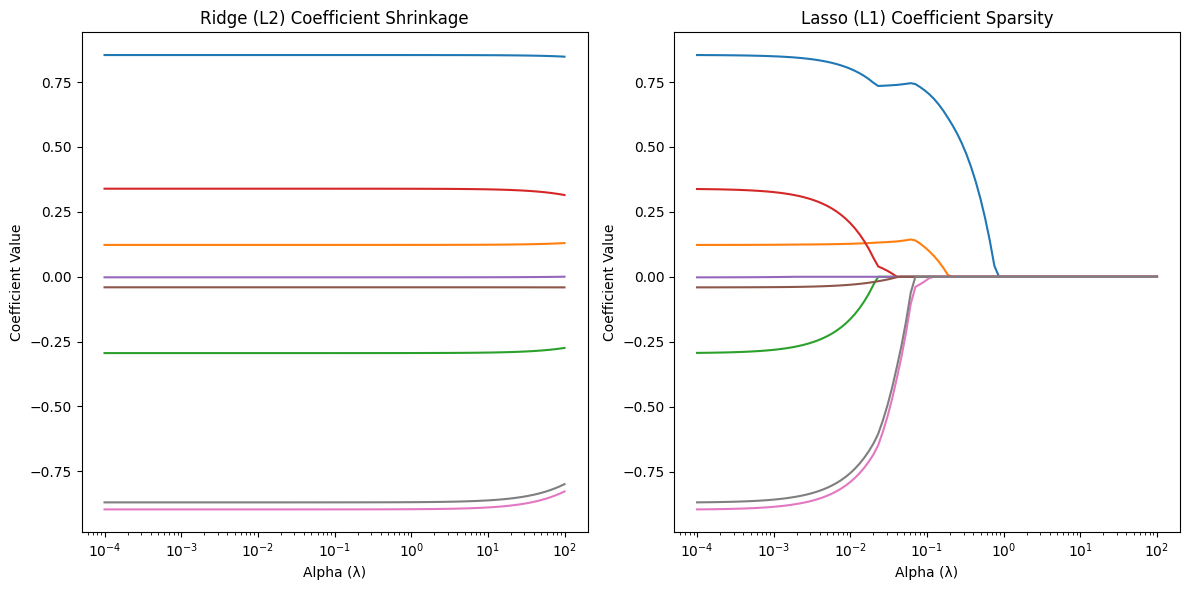

In [6]:

# Plot coefficient paths
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.title("Ridge (L2) Coefficient Shrinkage")
plt.xlabel("Alpha (λ)")
plt.ylabel("Coefficient Value")

plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_coefs)
plt.xscale('log')
plt.title("Lasso (L1) Coefficient Sparsity")
plt.xlabel("Alpha (λ)")
plt.ylabel("Coefficient Value")

plt.tight_layout()
plt.show()




L2 (Ridge): Coefficients shrink smoothly but never reach zero.
L1 (Lasso): Coefficients hit zero abruptly (sparsity).
7. When to Use Which?

Use Case	Recommended Regularization
Feature selection (high dimensions)	Lasso (L1)
General overfitting prevention	Ridge (L2)
Balanced approach	Elastic Net (L1 + L2)
Handling multicollinearity	Ridge (L2)
Conclusion

L2 (Ridge) is better for general overfitting prevention.
L1 (Lasso) is better for feature selection.
Elastic Net combines both for a balanced approach.
Would you like an example with custom synthetic data? 🚀